## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Load Engineered Dataset

The engineered dataset created during exploratory data analysis is loaded for baseline regression modeling.

In [2]:
df = pd.read_csv("steel_energy_engineered.csv")

print(df.shape)
df.head()

(35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117,0


In [3]:
print(df.isnull().sum())

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Day                                     0
Month                                   0
Day_Type                                0
Power_Factor_Ratio                      1
High_Load                               0
dtype: int64


In [4]:
# Check the problematic row
df[df['Power_Factor_Ratio'].isnull()]

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day,Month,Day_Type,Power_Factor_Ratio,High_Load
29855,2018-11-07 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,Weekday,Wednesday,Light_Load,0,Wednesday,11,Weekday,NaN,0


In [5]:
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].fillna(0)

In [6]:
print(df['Power_Factor_Ratio'].isnull().sum())

0


In [7]:
df.to_csv("steel_energy_engineered.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [8]:
df = pd.read_csv("steel_energy_engineered.csv")

print(df.isnull().sum())

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Day                                     0
Month                                   0
Day_Type                                0
Power_Factor_Ratio                      0
High_Load                               0
dtype: int64


## Remove Unnecessary Columns

The `date` column is removed because its information has already been extracted into time-based features. The `High_Load` column is also removed because it is derived directly from the target variable (`Usage_kWh`) and would cause data leakage.

In [9]:
df = df.drop(columns=['date', 'High_Load'])

print(df.columns)

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day', 'Month',
       'Day_Type', 'Power_Factor_Ratio'],
      dtype='object')


## Encode Categorical Variables

One-Hot Encoding is applied to categorical variables because these features do not have any natural ordering.

In [10]:
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'Day', 'Day_Type']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print(df.shape)
df.head()

(35040, 26)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Month,Power_Factor_Ratio,...,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Day_Type_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1,1.365934,...,0,0,0,1,0,0,0,0,0,0
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1,1.497679,...,0,0,0,1,0,0,0,0,0,0
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1,1.422880,...,0,0,0,1,0,0,0,0,0,0
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1,1.468644,...,0,0,0,1,0,0,0,0,0,0
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1,1.545117,...,0,0,0,1,0,0,0,0,0,0


## Define Features and Target Variable

The target variable is `Usage_kWh`, while the remaining columns are used as input features.

In [11]:
X = df.drop('Usage_kWh', axis=1)
y = df['Usage_kWh']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (35040, 25)
y Shape: (35040,)


In [12]:
print("NaN in X:", X.isnull().sum().sum())

NaN in X: 0


## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("NaN in X_train:", X_train.isnull().sum().sum())

Training Shape: (28032, 25)
Testing Shape: (7008, 25)
NaN in X_train: 0


## Model 1: Linear Regression

Linear Regression is used as the first baseline model to predict energy consumption.

In [14]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", round(lr_mae,4))
print("RMSE:", round(lr_rmse,4))
print("R²  :", round(lr_r2,4))

Linear Regression
MAE : 2.6134
RMSE: 4.1405
R²  : 0.9849


## Model 2: Ridge Regression

Ridge Regression applies L2 regularization to reduce overfitting.

In [15]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("MAE :", round(ridge_mae,4))
print("RMSE:", round(ridge_rmse,4))
print("R²  :", round(ridge_r2,4))

Ridge Regression
MAE : 4.319
RMSE: 6.2445
R²  : 0.9657


## Model 3: Decision Tree Regressor

Decision Tree Regression captures non-linear relationships in the data.

In [16]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", round(dt_mae,4))
print("RMSE:", round(dt_rmse,4))
print("R²  :", round(dt_r2,4))

Decision Tree
MAE : 0.5471
RMSE: 1.5369
R²  : 0.9979


## Model 4: Random Forest Regressor

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", round(rf_mae,4))
print("RMSE:", round(rf_rmse,4))
print("R²  :", round(rf_r2,4))

Random Forest
MAE : 0.3502
RMSE: 1.0306
R²  : 0.9991


## Model Performance Comparison

The performance of all baseline regression models is compared using MAE, RMSE, and R² Score.

In [18]:
results = pd.DataFrame({
    'Model': ['Linear Regression',
              'Ridge Regression',
              'Decision Tree',
              'Random Forest'],
    'MAE': [lr_mae, ridge_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, ridge_rmse, dt_rmse, rf_rmse],
    'R2 Score': [lr_r2, ridge_r2, dt_r2, rf_r2]
})

results = results.round(4)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.6134,4.1405,0.9849
1,Ridge Regression,4.3190,6.2445,0.9657
2,Decision Tree,0.5471,1.5369,0.9979
3,Random Forest,0.3502,1.0306,0.9991


## 5-Fold Cross Validation

Cross-validation is performed to evaluate the stability and generalization performance of each regression model.

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    print(f"{name}")
    print("Average R²:", round(scores.mean(),4))
    print("-"*40)

Linear Regression
Average R²: 0.9804
----------------------------------------
Ridge Regression
Average R²: 0.9589
----------------------------------------
Decision Tree
Average R²: 0.9918
----------------------------------------
Random Forest
Average R²: 0.993
----------------------------------------


## RMSE Comparison

Lower RMSE values indicate better prediction performance.

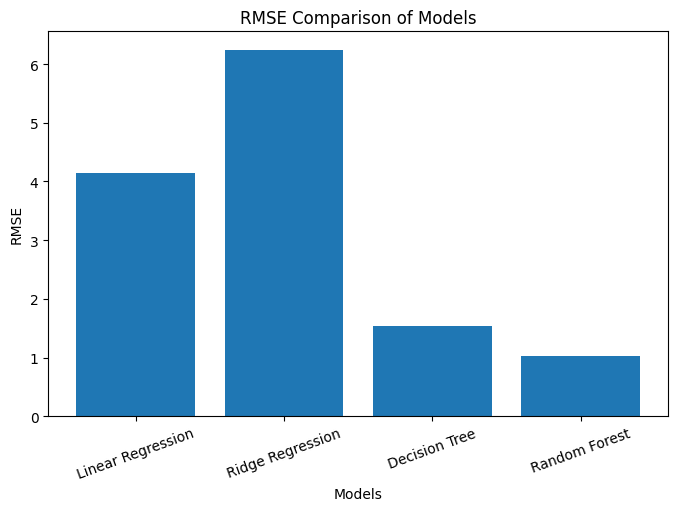

In [20]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.title("RMSE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

## Predicted vs Actual Values

The scatter plot compares actual energy consumption values with the predictions generated by the best-performing model.

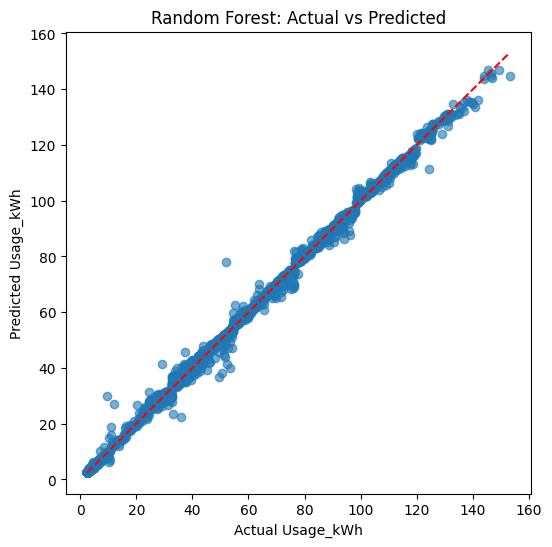

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

## Model Selection

Four baseline regression models were evaluated to predict steel industry energy consumption.

Among all models, the **Random Forest Regressor** achieved the best performance with the lowest MAE and RMSE values and the highest R² score. This indicates that Random Forest produced the most accurate predictions and generalized well to unseen data.

Decision Tree Regression also performed exceptionally well, while Linear Regression and Ridge Regression achieved good performance but were less accurate for this dataset due to its non-linear relationships.

Therefore, **Random Forest Regressor** is selected as the best baseline model for this task because it provides the highest predictive accuracy and the most reliable overall performance.